# Neural Rendering

## Data Preperation


In [71]:
import os
import json
import random
from typing import Optional, Tuple, List, Dict, Literal

import torch
from torch import Tensor
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms
from torchvision.transforms import Compose

SplitType = Literal["train", "val", "test"]

class PhongDataset(Dataset[Tuple[Tensor, Tensor]]):
    def __init__(
        self,
        base_path: str,
        split: SplitType = "train",
        split_ratio: Tuple[float, float, float] = (0.8, 0.1, 0.1),
        transform: Optional[Compose] = None,
        cache_images: bool = False,
        seed: int = 42,
    ) -> None:
        self.image_path = os.path.join(base_path, "images")
        self.json_path = os.path.join(base_path, "dataset.json")
        self.transform = transform or transforms.ToTensor()
        self.cache_images = cache_images

        with open(self.json_path, "r") as f:
            all_samples: List[Dict] = json.load(f)

        random.seed(seed)
        random.shuffle(all_samples)
        total = len(all_samples)
        train_end = int(total * split_ratio[0])
        val_end = train_end + int(total * split_ratio[1])

        if split == "train":
            self.samples = all_samples[:train_end]
        elif split == "val":
            self.samples = all_samples[train_end:val_end]
        elif split == "test":
            self.samples = all_samples[val_end:]
        else:
            raise ValueError(f"Invalid split: {split}")

        self.image_cache: Dict[str, Tensor] = {}
        if self.cache_images:
            print(f"Caching {len(self.samples)} images in memory for split '{split}'...")
            for entry in self.samples:
                image_path = os.path.join(self.image_path, entry["image_filename"])
                img = Image.open(image_path).convert("RGB")
                self.image_cache[entry["image_filename"]] = self.transform(img)

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int) -> Tuple[Tensor, Tensor]:
        entry = self.samples[idx]
        input_vec: List[float] = (
            entry["model_translation_relative"] +
            entry["material_diffuse"] +
            [entry["material_shininess"]] +
            entry["light_position"]
        )
        input_tensor: Tensor = torch.tensor(input_vec, dtype=torch.float32)

        if self.cache_images:
            target_tensor = self.image_cache[entry["image_filename"]]
        else:
            image = Image.open(os.path.join(self.image_path, entry["image_filename"])).convert("RGB")
            target_tensor = self.transform(image)

        return input_tensor, target_tensor

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [135]:
%env BASE_DATA_PATH=/content/drive/MyDrive/data/phong

env: BASE_DATA_PATH=/content/drive/MyDrive/data/phong


In [ ]:
from torch.utils.data import DataLoader

base_path = os.getenv("BASE_DATA_PATH")
dataset_version = "v6"
dataset_path = os.path.join(base_path, dataset_version)

train_set = PhongDataset(dataset_path, split="train", cache_images=True)
val_set = PhongDataset(dataset_path, split="val", cache_images=True)
test_set = PhongDataset(dataset_path, split="test", cache_images=False)

batch_size = 32
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size)
test_loader = DataLoader(test_set, batch_size=batch_size)

for inputs, images in test_loader:
    print("Input shape:", inputs.shape)
    print("Output shape:", images.shape)
    break

Caching 8000 images in memory for split 'train'...


## Model Architectures

In [9]:
import torch
import torch.nn as nn

class PhongMLPGeneratorV2(nn.Module):
    def __init__(self, input_dim: int = 10, output_shape: tuple = (3, 128, 128)):
        super().__init__()
        self.output_shape = output_shape
        self.latent_size = 8

        self.fc = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, 2048),
            nn.ReLU(),
            nn.Linear(2048, 256 * self.latent_size * self.latent_size),
            nn.ReLU()
        )

        self.upsample = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(256, 128, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(32, 3, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.fc(x)
        x = x.view(-1, 256, self.latent_size, self.latent_size)
        return self.upsample(x)


In [10]:
import torch
import torch.nn as nn

class PhongDiscriminator(nn.Module):
    def __init__(self, input_channels: int = 3):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(input_channels, 64, 4, stride=2, padding=1),  # 64x64
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, stride=2, padding=1),  # 32x32
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, stride=2, padding=1),  # 16x16
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 512, 4, stride=2, padding=1),  # 8x8
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),

            nn.Flatten(),  # Przekształcenie do jednego wektora
            nn.Linear(512 * 8 * 8, 1),  # Jedna wartość dla całego obrazu
            nn.Sigmoid()  # prawdopodobieństwo realistyczności obrazu
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)


In [72]:
model = PhongMLPGeneratorV2(input_dim=10, output_shape=(3, 128, 128))
for inputs, images in train_loader:
    print("Input shape:", inputs.shape)
    print("Output shape:", images.shape)

    output = model(inputs)
    print("Model output shape:", output.shape)
    break

Input shape: torch.Size([32, 10])
Output shape: torch.Size([32, 3, 128, 128])
Model output shape: torch.Size([32, 3, 128, 128])


## Training

### Experiment tracking setup

In [12]:
! pip install -q neptune

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 487.9/487.9 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.9/139.9 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 130.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 6.5 MB/s eta 0:00:00


In [13]:
import neptune

In [14]:
NEPTUNE_PROJECT_NAME = "sigk/neural-rendering"
NEPTUNE_API_KEY = input("Enter Neptune API key: ")

Enter Neptune API key: eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiI4ODA4YThkMy04N2Y5LTQ4NzItYmExMi1hNDdkM2Y4ZTJiNWYifQ==


In [15]:
! pip install -q flip-evaluator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.3/417.3 kB 8.8 MB/s eta 0:00:00


In [17]:
import os
import flip_evaluator as flip
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.utils import save_image

### Results plotting

In [114]:
import matplotlib.pyplot as plt
import torch

def plot_predictions(
    model: torch.nn.Module,
    test_loader: torch.utils.data.DataLoader,
    n: int = 5,
    show: bool = True,
    device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
) -> None:
    model.eval()
    fig, axes = plt.subplots(2, n, figsize=(2 * n, 4))

    with torch.no_grad():
        for i, (inputs, targets) in enumerate(test_loader):
            if i >= n:
                break

            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)

            ax_gt = axes[0, i]
            ax_gt.imshow(targets[0].cpu().permute(1, 2, 0).numpy())

            ax_pred = axes[1, i]
            ax_pred.imshow(outputs[0].cpu().permute(1, 2, 0).numpy())

        axes[0, 0].set_ylabel('Ground Truth', fontsize=12, fontweight='bold')
        axes[1, 0].set_ylabel('Prediction', fontsize=12, fontweight='bold')

        for ax in axes.flat:
            ax.set_xticks([])
            ax.set_yticks([])

    plt.tight_layout(pad=0.5)
    if show:
        plt.show()

    plt.close()
    return fig


### Training loop - generator only




In [13]:
def train_phong_generator(
    model: nn.Module,
    optimizer: optim.Optimizer,
    criterion: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    num_epochs: int = 10,
    run: neptune.Run | None = None,
    device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
) -> None:
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)

            loss = criterion(outputs, targets)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            if run:
                run["train/step/loss"].append(loss.item())

        avg_train_loss = total_loss / len(train_loader)

        if run:
          run["train/epoch/loss"].append(avg_train_loss)

        model.eval()
        val_loss = 0.0
        val_flip = 0.0
        with torch.no_grad():
            for val_inputs, val_targets in val_loader:
                val_inputs, val_targets = val_inputs.to(device), val_targets.to(device)
                val_outputs = model(val_inputs)

                loss = criterion(val_outputs, val_targets)
                val_loss += loss.item()
                if run:
                    run["val/step/loss"].append(loss.item())

                for i in range(val_outputs.size(0)):
                    pred = val_outputs[i].cpu().permute(1, 2, 0).numpy()
                    ref = val_targets[i].cpu().permute(1, 2, 0).numpy()
                    flip_error_map, mean_flip_error, parameters = flip.evaluate(ref, pred, "LDR")
                    val_flip += mean_flip_error

                    if run:
                        run["val/step/flip"].append(mean_flip_error)

        avg_val_loss = val_loss / len(val_loader)
        avg_flip = val_flip / (len(val_loader.dataset))

        if run:
            run["val/epoch/loss"].append(avg_val_loss)
            run["val/epoch/flip"].append(avg_flip)

        print(f"[Epoch {epoch+1}] Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | FLIP: {avg_flip:.4f}")


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PhongMLPGeneratorV2()
model = model.to(device)
criterion = nn.MSELoss()
lr: float = 1e-4
optimizer = optim.Adam(model.parameters(), lr=lr)
epochs=5

In [ ]:
run = neptune.init_run(
    project=NEPTUNE_PROJECT_NAME,
    api_token=NEPTUNE_API_KEY,
)
params = {
    "model_name": model.__class__.__name__,
    "optimizer_name": optimizer.__class__.__name__,
    "learning_rate": lr,
    "epochs": epochs,
    "dataset_size": len(train_set),
    "batch_size": 32,
}
run["parameters"] = params

In [ ]:
train_phong_generator(
    model,
    optimizer,
    criterion,
    train_loader,
    val_loader,
    num_epochs=epochs,
    run=run,
)

### Training loop GAN

In [117]:
def train_gan(
    generator: nn.Module,
    discriminator: nn.Module,
    generator_optimizer: optim.Optimizer,
    discriminator_optimizer: optim.Optimizer,
    train_loader: DataLoader,
    val_loader: DataLoader,
    num_epochs: int = 20,
    lambda_l1: float = 100.0,
    run: neptune.Run | None = None,
    device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
) -> None:
    generator = generator.to(device)
    discriminator = discriminator.to(device)

    adversarial_loss = nn.MSELoss() # nn.BCEWithLogitsLoss()
    if run:
        run["parameters/adversarial_loss"] = adversarial_loss.__class__.__name__
    l1_loss = nn.L1Loss()

    for epoch in range(num_epochs):
        generator.train()
        discriminator.train()
        G_loss_total = 0
        D_loss_total = 0

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            batch_size = inputs.size(0)

            # real_labels = torch.ones((batch_size, 1), device=device)
            real_labels = torch.full((batch_size, 1), 0.9, device=device) # label smoothing
            fake_labels = torch.zeros((batch_size, 1), device=device)

            ### === Train Discriminator ===
            optimizer_D.zero_grad()
            real_preds = discriminator(targets)
            real_loss = adversarial_loss(real_preds, real_labels)

            fake_images = generator(inputs).detach()
            fake_preds = discriminator(fake_images)
            fake_loss = adversarial_loss(fake_preds, fake_labels)

            loss_D = (real_loss + fake_loss) / 2
            loss_D.backward()
            optimizer_D.step()

            ### === Train Generator ===
            optimizer_G.zero_grad()
            gen_images = generator(inputs)
            preds = discriminator(gen_images)
            loss_G_adv = adversarial_loss(preds, real_labels)
            loss_G_l1 = l1_loss(gen_images, targets)

            loss_G = loss_G_adv + lambda_l1 * loss_G_l1
            loss_G.backward()
            optimizer_G.step()

            G_loss_total += loss_G.item()
            D_loss_total += loss_D.item()

            if run:
                run["train/step/g_loss"].append(loss_G.item())
                run["train/step/d_loss"].append(loss_D.item())

        print(f"[Epoch {epoch+1}] G Loss: {G_loss_total/len(train_loader):.4f} | D Loss: {D_loss_total/len(train_loader):.4f}")

        if run:
            fig = plot_predictions(G, test_loader, n=4, show=False)
            run[f"train/epoch/{epoch+1}_sample"].upload(fig)

            run["train/epoch/g_loss"].append(G_loss_total / len(train_loader))
            run["train/epoch/d_loss"].append(D_loss_total / len(train_loader))


In [126]:
device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
G = PhongMLPGeneratorV2()
D = PhongDiscriminator()
G = G.to(device)
D = D.to(device)

lr_G = 1e-4
lr_D = 1e-5
optimizer_G = optim.Adam(G.parameters(), lr=lr_G, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=lr_G, betas=(0.5, 0.999))
epochs=50
lambda_l1=100

In [127]:
run = neptune.init_run(
    project=NEPTUNE_PROJECT_NAME,
    api_token=NEPTUNE_API_KEY,
)
params = {
    "generator_name": G.__class__.__name__,
    "discriminator_name": D.__class__.__name__,
    "generator_optimizer_name": optimizer_G.__class__.__name__,
    "discriminator_optimizer_name": optimizer_D.__class__.__name__,
    "generator_learning_rate": lr_G,
    "discriminator_learning_rate": lr_D,
    "lambda_l1": lambda_l1,
    "epochs": epochs,
    "dataset_size": len(train_set),
    "dataset_version": dataset_version,
    "batch_size": batch_size,
}
run["parameters"] = params

[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/sigk/neural-rendering/e/NEUR-19


In [128]:
train_gan(
    G,
    D,
    optimizer_G,
    optimizer_D,
    train_loader=train_loader,
    val_loader=val_loader,
    lambda_l1=lambda_l1,
    num_epochs=epochs,
    run=run,
)

[Epoch 1] G Loss: 33.1354 | D Loss: 0.0105
[Epoch 2] G Loss: 19.4659 | D Loss: 0.0056
[Epoch 3] G Loss: 13.8178 | D Loss: 0.0050
[Epoch 4] G Loss: 10.4470 | D Loss: 0.0304
[Epoch 5] G Loss: 8.6233 | D Loss: 0.0173
[Epoch 6] G Loss: 7.5828 | D Loss: 0.0064
[Epoch 7] G Loss: 5.9985 | D Loss: 0.0063
[Epoch 8] G Loss: 6.0768 | D Loss: 0.0452
[Epoch 9] G Loss: 5.0167 | D Loss: 0.0050
[Epoch 10] G Loss: 4.4638 | D Loss: 0.0052
[Epoch 11] G Loss: 4.1487 | D Loss: 0.0050
[Epoch 12] G Loss: 3.8164 | D Loss: 0.0050
[Epoch 13] G Loss: 3.6560 | D Loss: 0.0050
[Epoch 14] G Loss: 3.5724 | D Loss: 0.0050
[Epoch 15] G Loss: 3.4979 | D Loss: 0.0056
[Epoch 16] G Loss: 3.3295 | D Loss: 0.0050
[Epoch 17] G Loss: 2.9824 | D Loss: 0.0050
[Epoch 18] G Loss: 2.7262 | D Loss: 0.0050
[Epoch 19] G Loss: 2.6469 | D Loss: 0.0050
[Epoch 20] G Loss: 2.5571 | D Loss: 0.0050
[Epoch 21] G Loss: 2.5310 | D Loss: 0.0050
[Epoch 22] G Loss: 2.4219 | D Loss: 0.0053
[Epoch 23] G Loss: 2.3779 | D Loss: 0.0050
[Epoch 24] G Los

In [129]:
def test_model(
    model: nn.Module,
    test_loader: DataLoader,
    run: neptune.Run | None = None,
    device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
) -> None:
    model.eval()
    test_flip = 0.0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)

            for i in range(outputs.size(0)):
                pred = outputs[i].cpu().permute(1, 2, 0).numpy()
                ref = targets[i].cpu().permute(1, 2, 0).numpy()
                flip_error_map, mean_flip_error, parameters = flip.evaluate(ref, pred, "LDR")
                test_flip += mean_flip_error

                if run:
                    run["test/step/flip"].append(mean_flip_error)

    avg_flip = test_flip / (len(val_loader.dataset))
    if run:
        run["test/flip"].append(avg_flip)
    print(f"FLIP: {avg_flip:.4f}")


In [130]:
test_model(G, test_loader, run=run)

FLIP: 0.0280


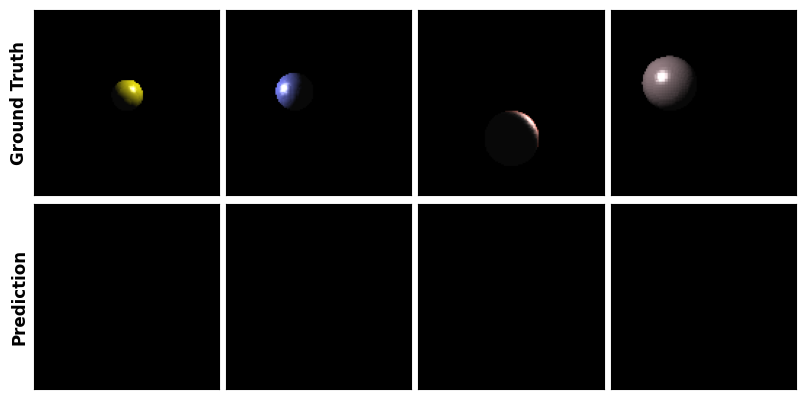

In [131]:
fig = plot_predictions(G, test_loader, n=4)

In [132]:
run["test/sample"].upload(fig)

In [134]:
run.stop()